Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      122 non-null    object 
 1   Gender           119 non-null    object 
 2   Age              120 non-null    float64
 3   City             122 non-null    object 
 4   Monthly_Income   119 non-null    float64
 5   Purchase_Amount  119 non-null    float64
 6   Satisfaction     122 non-null    int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 6.8+ KB

Missing Values:
Customer_ID        0
Gender             3
Age                2
City               0
Monthly_Income     3
Purchase_Amount    3
Satisfaction       0
dtype: int64


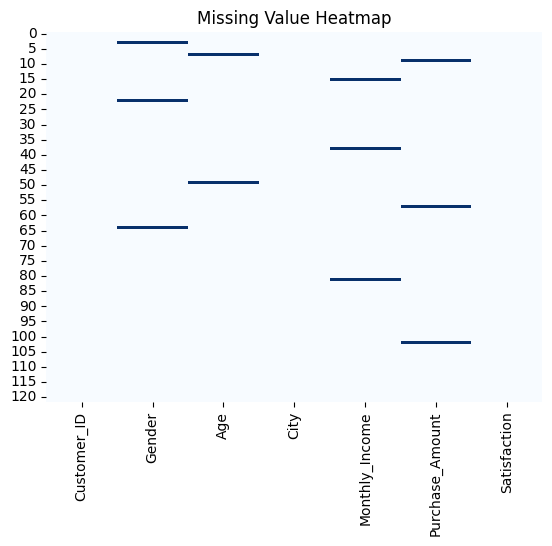

Duplicate rows removed: 2

Cleaned Data Summary:
<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      120 non-null    object 
 1   Gender           120 non-null    object 
 2   Age              120 non-null    float64
 3   City             120 non-null    object 
 4   Monthly_Income   120 non-null    float64
 5   Purchase_Amount  120 non-null    float64
 6   Satisfaction     120 non-null    int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 7.5+ KB


,Customer_ID,Gender,Age,City,Monthly_Income,Purchase_Amount,Satisfaction
0,C001,Male,-0.219848,Salem,0.687359,0.735548,3
1,C002,Male,0.281980,Madurai,0.521420,0.867997,4
2,C003,Male,-0.578297,Chennai,0.449088,0.548459,5
3,C004,Male,1.213946,Salem,0.678946,0.652411,4
4,C005,Male,-1.295194,Madurai,0.649455,0.099846,2


Cleaned data saved successfully.


In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv("/content/exp3_data_cleaning_120.csv")

print("Initial Data Overview:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()

for col in ["Gender", "City"]:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in ["Age", "Monthly_Income", "Purchase_Amount", "Satisfaction"]:
    df[col] = df[col].fillna(df[col].median())

initial_rows = len(df)
df.drop_duplicates(inplace=True)
print("Duplicate rows removed:", initial_rows - len(df))

df["Gender"] = df["Gender"].astype(str).str.strip().str.capitalize()
df["City"] = df["City"].astype(str).str.strip()

minmax = MinMaxScaler()
df[["Monthly_Income", "Purchase_Amount"]] = minmax.fit_transform(
    df[["Monthly_Income", "Purchase_Amount"]]
)

standard = StandardScaler()
df[["Age"]] = standard.fit_transform(df[["Age"]])

print("\nCleaned Data Summary:")
df.info()
display(df.head())

df.to_csv("/content/cleaned_customer_data.csv", index=False)
print("Cleaned data saved successfully.")